In [36]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
# ROC Curve e AUC (multiclasse - One-vs-Rest)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [37]:
# Configurar device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando device: {device}")

Usando device: cpu


Shape dos dados: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
31                 5.4               3.4                1.5               0.4   
100                6.3               3.3                6.0               2.5   
2                  4.7               3.2                1.3               0.2   
130                7.4               2.8                6.1               1.9   
28                 5.2               3.4                1.4               0.2   

     target  
31        0  
100       2  
2         0  
130       2  
28        0  


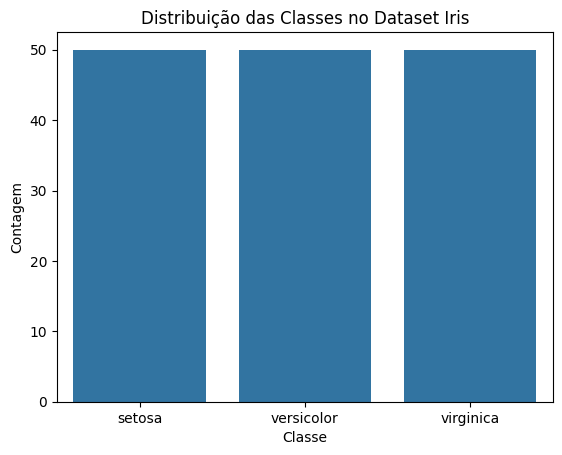

In [38]:
# Dataset - Carregamento do dataset Iris
iris = load_iris()
X, y = iris.data, iris.target
print(f"Shape dos dados: {X.shape}")
print(f"Classes: {iris.target_names}")
print(f"Features: {iris.feature_names}")

## Converte o dataset para um DataFrame do pandas para melhor visualização
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
print(df.sample(5))

# Verificacao do balancemaento das classes
# Um grafico de barras para mostrar a distribuicao das classes
sns.countplot(x='target', data=df)
plt.title('Distribuição das Classes no Dataset Iris')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.xticks(ticks=[0, 1, 2], labels=iris.target_names)
plt.show()



In [39]:
# Pré-processamento - Normalização dos dados com scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Dados normalizados com StandardScaler")

Dados normalizados com StandardScaler


In [40]:
# Divisão (train / validation / test)
# Dividir em treino (60%), validação (20%) e teste (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# veificar se stá balanceado
print(f"Treino: {np.bincount(y_train)}")
print(f"Validação: {np.bincount(y_val)}")
print(f"Teste: {np.bincount(y_test)}")

# Converter para tensors
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.LongTensor(y_val).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Validação: {X_val.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

Treino: [30 30 30]
Validação: [10 10 10]
Teste: [10 10 10]
Treino: 90 amostras
Validação: 30 amostras
Teste: 30 amostras


In [41]:
# Arquitetura da MLP
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x

# Parâmetros do modelo
input_size = 4  # 4 features do Iris
hidden_size = 4
num_classes = 3  # 3 espécies de Iris
learning_rate = 0.001
num_epochs = 200

# Instanciar modelo
model = MLP(input_size, hidden_size, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"Modelo criado com arquitetura: {input_size} -> {hidden_size} -> {hidden_size} -> {num_classes}")

Modelo criado com arquitetura: 4 -> 4 -> 4 -> 3


In [42]:
# Treinamento
# Listas para armazenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Função para calcular acurácia
def calculate_accuracy(outputs, targets):
    _, predicted = torch.max(outputs.data, 1)
    total = targets.size(0)
    correct = (predicted == targets).sum().item()
    return 100 * correct / total

print("Iniciando treinamento...")
for epoch in range(num_epochs):
    # Modo treino
    model.train()
    train_outputs = model(X_train_tensor)
    train_loss = criterion(train_outputs, y_train_tensor)
    
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()
    
    # Avaliação no conjunto de validação
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        
        # Calcular acurácias
        train_acc = calculate_accuracy(train_outputs, y_train_tensor)
        val_acc = calculate_accuracy(val_outputs, y_val_tensor)
        
        # Armazenar métricas
        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
    
    # Print a cada 20 epochs
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {train_loss.item():.4f}, Train Acc: {train_acc:.2f}%, '
              f'Val Loss: {val_loss.item():.4f}, Val Acc: {val_acc:.2f}%')

print("Treinamento concluído!")

Iniciando treinamento...
Epoch [20/200], Train Loss: 1.1140, Train Acc: 33.33%, Val Loss: 1.1129, Val Acc: 33.33%
Epoch [40/200], Train Loss: 1.1059, Train Acc: 33.33%, Val Loss: 1.1046, Val Acc: 33.33%
Epoch [60/200], Train Loss: 1.0976, Train Acc: 33.33%, Val Loss: 1.0961, Val Acc: 33.33%
Epoch [80/200], Train Loss: 1.0868, Train Acc: 33.33%, Val Loss: 1.0855, Val Acc: 33.33%
Epoch [100/200], Train Loss: 1.0720, Train Acc: 33.33%, Val Loss: 1.0710, Val Acc: 33.33%
Epoch [120/200], Train Loss: 1.0449, Train Acc: 41.11%, Val Loss: 1.0456, Val Acc: 43.33%
Epoch [140/200], Train Loss: 0.9951, Train Acc: 82.22%, Val Loss: 0.9967, Val Acc: 86.67%
Epoch [160/200], Train Loss: 0.9270, Train Acc: 90.00%, Val Loss: 0.9278, Val Acc: 90.00%
Epoch [180/200], Train Loss: 0.8445, Train Acc: 88.89%, Val Loss: 0.8447, Val Acc: 90.00%
Epoch [200/200], Train Loss: 0.7545, Train Acc: 90.00%, Val Loss: 0.7546, Val Acc: 86.67%
Treinamento concluído!


In [43]:
# Avaliação no conjunto de teste
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)
    test_acc = calculate_accuracy(test_outputs, y_test_tensor)
    
    # Predições detalhadas
    _, predicted = torch.max(test_outputs.data, 1)
    
print(f'\nResultados Finais:')
print(f'Acurácia no conjunto de teste: {test_acc:.2f}%')
print(f'Loss no conjunto de teste: {test_loss.item():.4f}')


Resultados Finais:
Acurácia no conjunto de teste: 76.67%
Loss no conjunto de teste: 0.7934


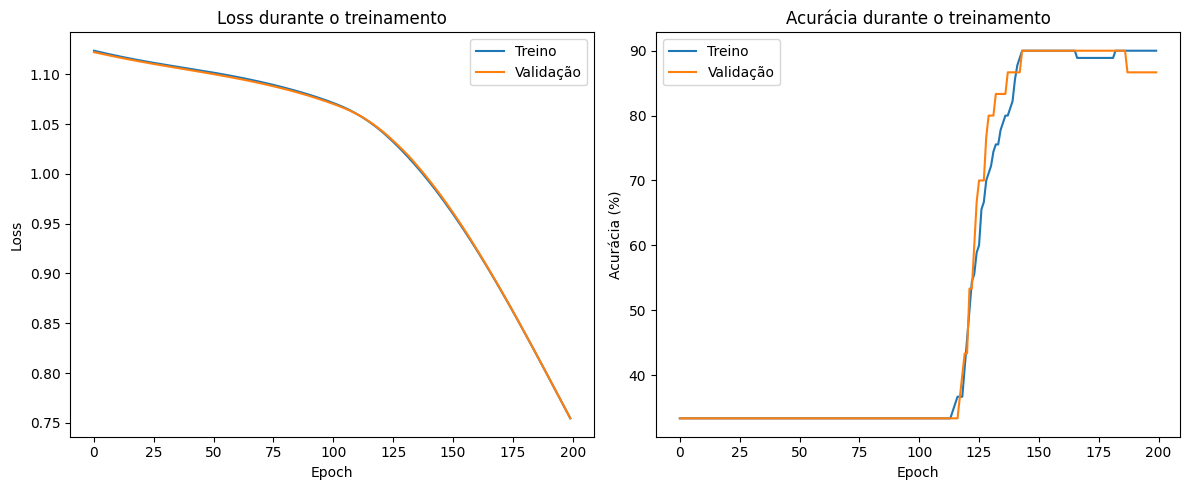

In [44]:
# Diagnóstico - Visualizar curvas de aprendizado
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Treino')
plt.plot(val_losses, label='Validação')
plt.title('Loss durante o treinamento')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Treino')
plt.plot(val_accuracies, label='Validação')
plt.title('Acurácia durante o treinamento')
plt.xlabel('Epoch')
plt.ylabel('Acurácia (%)')
plt.legend()

plt.tight_layout()
plt.show()

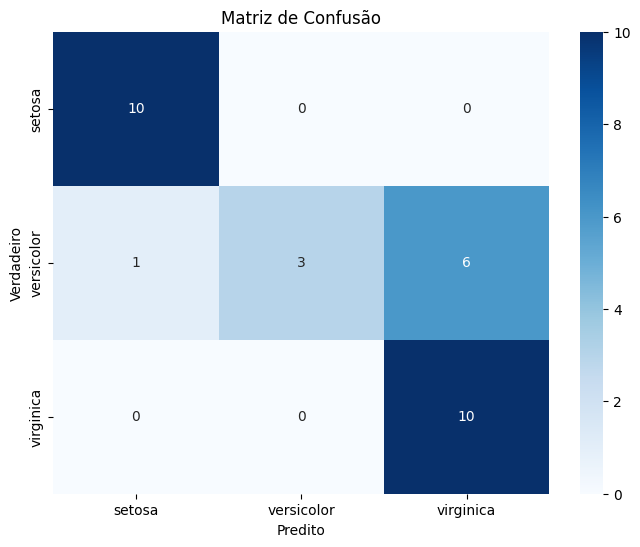


Relatório de Classificação:
              precision    recall  f1-score   support

      setosa       0.91      1.00      0.95        10
  versicolor       1.00      0.30      0.46        10
   virginica       0.62      1.00      0.77        10

    accuracy                           0.77        30
   macro avg       0.84      0.77      0.73        30
weighted avg       0.84      0.77      0.73        30



In [45]:
# Diagnóstico - Matriz de confusão
y_pred = predicted.cpu().numpy()
y_true = y_test

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, 
            yticklabels=iris.target_names)
plt.title('Matriz de Confusão')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.show()

print("\nRelatório de Classificação:")
print(classification_report(y_true, y_pred, target_names=iris.target_names))

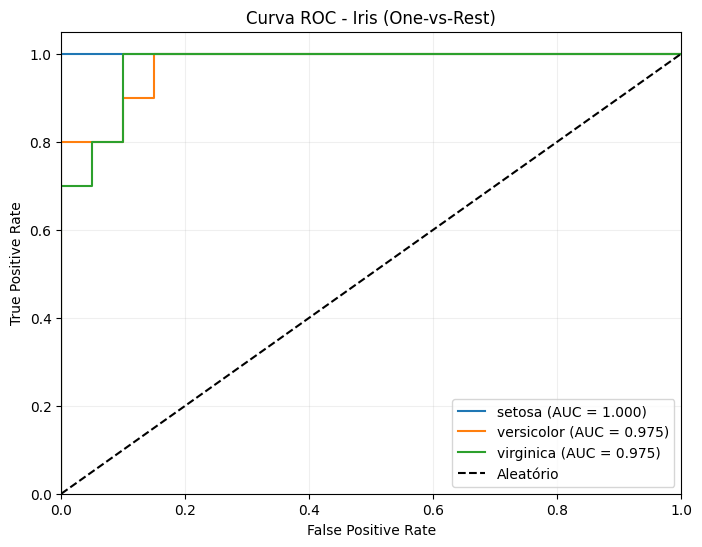

AUC Macro (OvR): 0.9833
AUC Weighted (OvR): 0.9833


In [46]:


model.eval()
with torch.no_grad():
    logits_test = model(X_test_tensor)
    y_score = torch.softmax(logits_test, dim=1).cpu().numpy()  # probabilidades por classe

y_true = y_test  # já está em numpy (0,1,2)
n_classes = len(iris.target_names)

# Binariza o target para ROC multiclasse
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot das curvas ROC por classe
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(
        fpr[i], tpr[i],
        label=f"{iris.target_names[i]} (AUC = {roc_auc[i]:.3f})"
    )

plt.plot([0, 1], [0, 1], "k--", label="Aleatório")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Iris (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

# AUC global
auc_macro = roc_auc_score(y_true_bin, y_score, multi_class="ovr", average="macro")
auc_weighted = roc_auc_score(y_true_bin, y_score, multi_class="ovr", average="weighted")
print(f"AUC Macro (OvR): {auc_macro:.4f}")
print(f"AUC Weighted (OvR): {auc_weighted:.4f}")

In [47]:
# Salvamento do modelo
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scaler': scaler,
    'model_params': {
        'input_size': input_size,
        'hidden_size': hidden_size,
        'num_classes': num_classes
    }
}, 'iris_mlp_model.pth')

print("Modelo salvo como 'iris_mlp_model.pth'")

Modelo salvo como 'iris_mlp_model.pth'
